#  Notebook 3 — Model Evaluation (YOLOv8)
**Steps:**
1. Load trained model
2. Run validation — mAP, Precision, Recall
3. Per-class metrics table
4. Confusion matrix
5. Loss & metric curves


In [3]:
# ============================================================
#  CONFIG
# ============================================================
PROJECT_DIR = "runs"         
RUN_NAME    = "egypt_yolo"    
DATA_YAML   = "data_local.yaml"  
IMG_SIZE    = 640            
BATCH_SIZE  = 8               
CONF_THRESH = 0.25            #  confidence threshold for evaluation
IOU_THRESH  = 0.5             #  IoU threshold for mAP

BEST_MODEL  = f"runs/detect/runs/egypt_yolo/weights/best.pt"

CLASSES = [
    "traffic light", "traffic sign", "car", "person", "bus",
    "truck", "rider", "bike", "motor", "train", "banner", "tuktuk"
]

print(f"Model: {BEST_MODEL}")

Model: runs/detect/runs/egypt_yolo/weights/best.pt


## Cell 1 — Load Model

In [4]:
import torch, os
from ultralytics import YOLO

DEVICE = 0 if torch.cuda.is_available() else 'cpu'

if not os.path.exists(BEST_MODEL):
    print(f"  Model not found: {BEST_MODEL}")
    print("   Run Notebook 2 first to train the model.")
else:
    model = YOLO(BEST_MODEL)
    print(f"   Loaded: {BEST_MODEL}")
    print(f"   Device : {DEVICE}")
    print(f"   Classes: {model.names}")

   Loaded: runs/detect/runs/egypt_yolo/weights/best.pt
   Device : 0
   Classes: {0: 'traffic light', 1: 'traffic sign', 2: 'car', 3: 'person', 4: 'bus', 5: 'truck', 6: 'rider', 7: 'bike', 8: 'motor', 9: 'train', 10: 'banner', 11: 'tuktuk'}


## Cell 2 — Full Validation (mAP, Precision, Recall)

In [5]:
metrics = model.val(
    data    = DATA_YAML,
    imgsz   = IMG_SIZE,
    batch   = BATCH_SIZE,
    conf    = CONF_THRESH,
    iou     = IOU_THRESH,
    device  = DEVICE,
    plots   = False,          # saves confusion matrix, P-R curve etc
    save_json = False,
)

print(f"\n{'='*40}")
print(f"  Overall Metrics")
print(f"{'='*40}")
print(f"   mAP@0.5      : {metrics.box.map50:.4f}")
print(f"   mAP@0.5:0.95 : {metrics.box.map:.4f}")
print(f"   Precision    : {metrics.box.mp:.4f}")
print(f"   Recall       : {metrics.box.mr:.4f}")

Ultralytics 8.4.30  Python-3.12.13 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
Model summary (fused): 93 layers, 25,846,708 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 268.5237.0 MB/s, size: 143.7 KB)
val: Scanning C:\Users\hp\Desktop\proj2\dataset\val\val\labels.cache... 6278 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 6278/6278  0.0s
val: C:\Users\hp\Desktop\proj2\dataset\val\val\images\person_200_jpg.rf.70b8c03f1b8cafe9f84fca25993bbc0b.jpg: 7 duplicate labels removed
WARNING Box and segment counts should be equal, but got len(segments) = 233, len(boxes) = 36235. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 785/785 10.0it/s 1:180.2sss
                   all       6278      362

## Cell 3 — Per-Class Metrics Table

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Per-class AP values from metrics
ap50_per_class = metrics.box.ap50   # AP@0.5 per class
ap_per_class   = metrics.box.ap     # AP@0.5:0.95 per class
p_per_class    = metrics.box.p      # Precision per class
r_per_class    = metrics.box.r      # Recall per class

print(f"{'Class':<15} {'P':>8} {'R':>8} {'AP@50':>8} {'AP@50-95':>10}")
print("-" * 52)
for i, cls in enumerate(CLASSES):
    if i < len(ap50_per_class):
        print(f"{cls:<15} {p_per_class[i]:>8.3f} {r_per_class[i]:>8.3f} "
              f"{ap50_per_class[i]:>8.3f} {ap_per_class[i]:>10.3f}")
print("-" * 52)
print(f"{'MEAN':<15} {metrics.box.mp:>8.3f} {metrics.box.mr:>8.3f} "
      f"{metrics.box.map50:>8.3f} {metrics.box.map:>10.3f}")

Class                  P        R    AP@50   AP@50-95
----------------------------------------------------
traffic light      0.881    0.668    0.807      0.572
traffic sign       0.851    0.738    0.832      0.660
car                0.907    0.880    0.928      0.807
person             0.855    0.779    0.854      0.614
bus                0.810    0.754    0.829      0.700
truck              0.735    0.667    0.743      0.608
rider              0.841    0.832    0.866      0.546
bike               0.760    0.594    0.709      0.442
motor              0.838    0.816    0.856      0.575
train              0.839    0.848    0.884      0.677
banner             0.799    0.881    0.890      0.712
tuktuk             0.894    0.908    0.944      0.815
----------------------------------------------------
MEAN               0.834    0.780    0.845      0.644


## Cell 4 — Per-Class Bar Chart

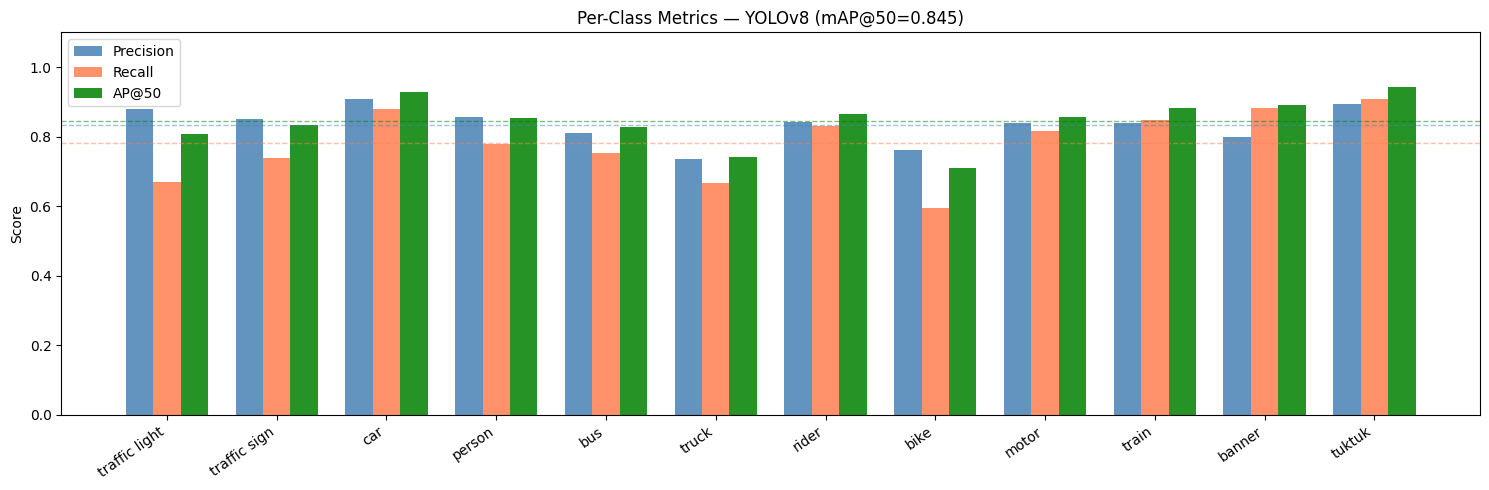

In [7]:
import matplotlib.pyplot as plt
import numpy as np

n = min(len(CLASSES), len(ap50_per_class))
x = np.arange(n)
w = 0.25

fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(x - w,   p_per_class[:n],    w, label='Precision', color='steelblue', alpha=0.85)
ax.bar(x,       r_per_class[:n],    w, label='Recall',    color='coral',     alpha=0.85)
ax.bar(x + w,   ap50_per_class[:n], w, label='AP@50',     color='green',     alpha=0.85)

ax.axhline(metrics.box.mp,   color='steelblue', linestyle='--', linewidth=1, alpha=0.5)
ax.axhline(metrics.box.mr,   color='coral',     linestyle='--', linewidth=1, alpha=0.5)
ax.axhline(metrics.box.map50,color='green',     linestyle='--', linewidth=1, alpha=0.5)

ax.set_xticks(x)
ax.set_xticklabels(CLASSES[:n], rotation=35, ha='right', fontsize=10)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title(f"Per-Class Metrics — YOLOv8 (mAP@50={metrics.box.map50:.3f})")
ax.legend()
plt.tight_layout()
# plt.savefig("per_class_metrics.png", dpi=150, bbox_inches='tight')
plt.show()

## Cell 5 — Plot Training Curves from CSV

Available columns: ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


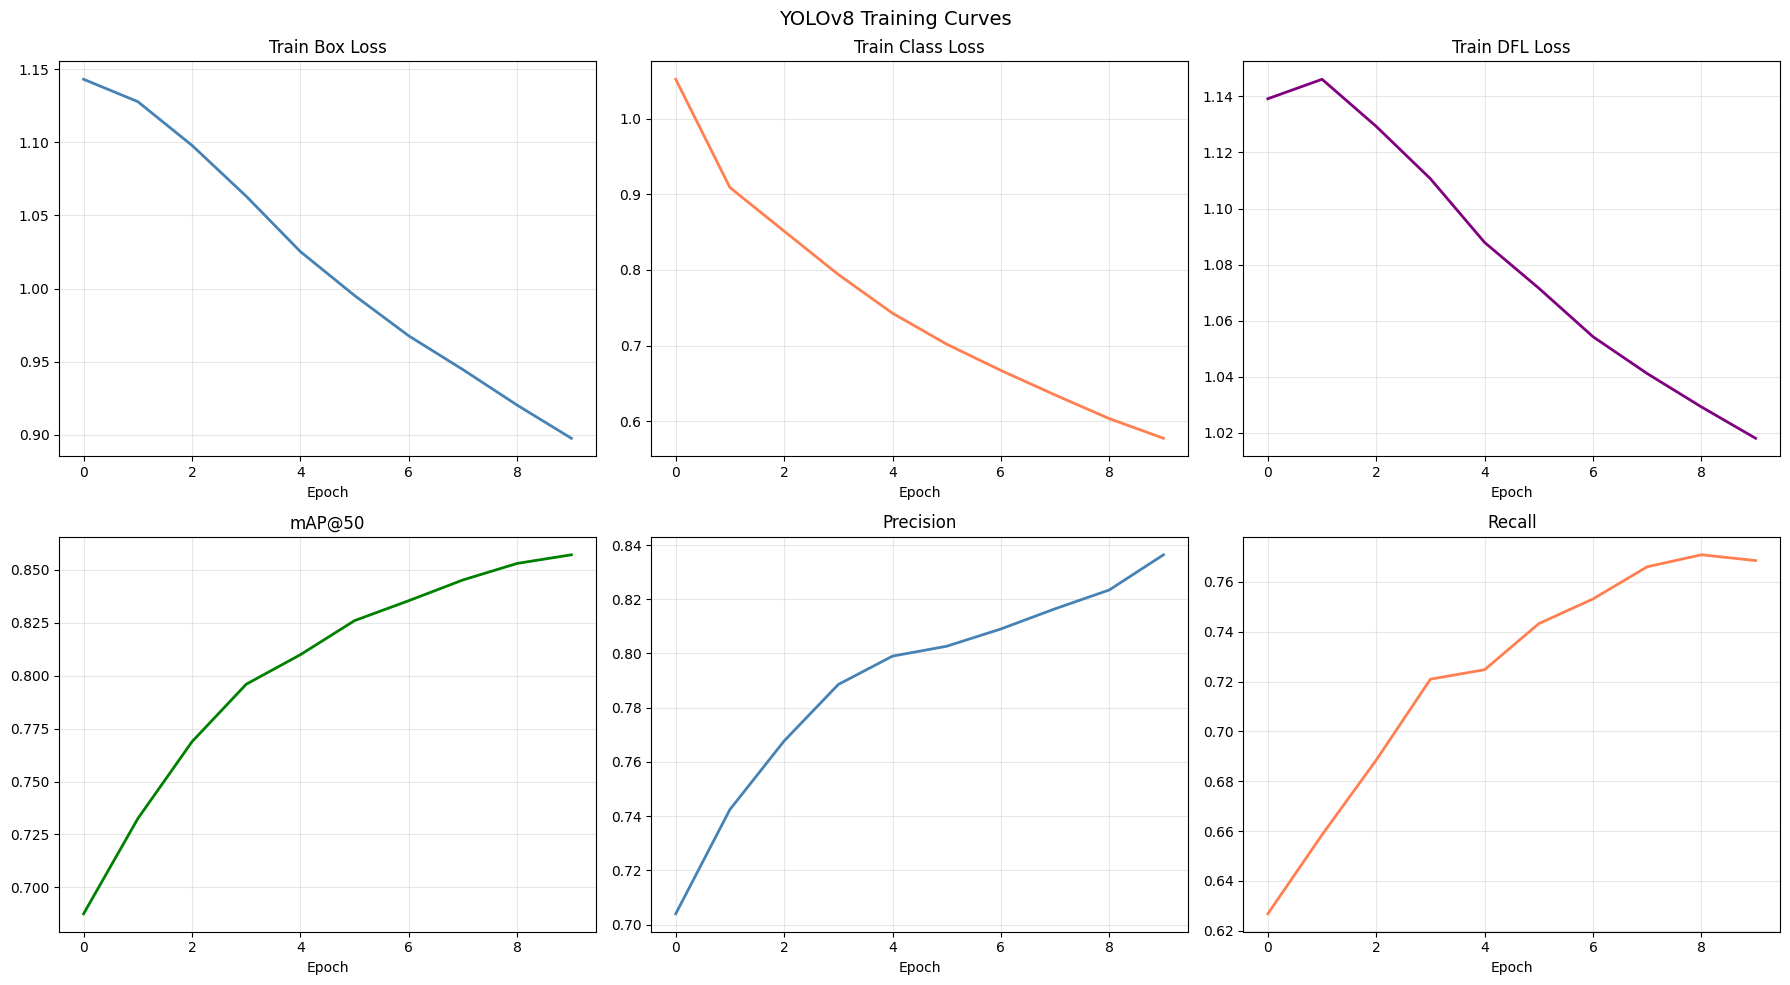

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# YOLOv8 auto-saves results.csv during training
csv_path = f"runs/detect/runs/egypt_yolo/results.csv"  

if not os.path.exists(csv_path):
    print(f"results.csv not found at: {csv_path}")
else:
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    print("Available columns:", df.columns.tolist())

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    def safe_plot(ax, col, title, color='steelblue'):
        if col in df.columns:
            ax.plot(df[col], color=color, linewidth=2)
            ax.set_title(title); ax.set_xlabel('Epoch')
            ax.grid(True, alpha=0.3)
        else:
            ax.set_title(f"{title} (not found)"); ax.axis('off')

    safe_plot(axes[0,0], 'train/box_loss',  'Train Box Loss',   'steelblue')
    safe_plot(axes[0,1], 'train/cls_loss',  'Train Class Loss', 'coral')
    safe_plot(axes[0,2], 'train/dfl_loss',  'Train DFL Loss',   'purple')
    safe_plot(axes[1,0], 'metrics/mAP50(B)','mAP@50',           'green')
    safe_plot(axes[1,1], 'metrics/precision(B)', 'Precision',   'steelblue')
    safe_plot(axes[1,2], 'metrics/recall(B)',    'Recall',       'coral')

    plt.suptitle("YOLOv8 Training Curves", fontsize=14)
    plt.tight_layout()
    # plt.savefig("training_curves.png", dpi=150, bbox_inches='tight')
    plt.show()
    

## Cell 6 — Show Auto-generated Plots from Training

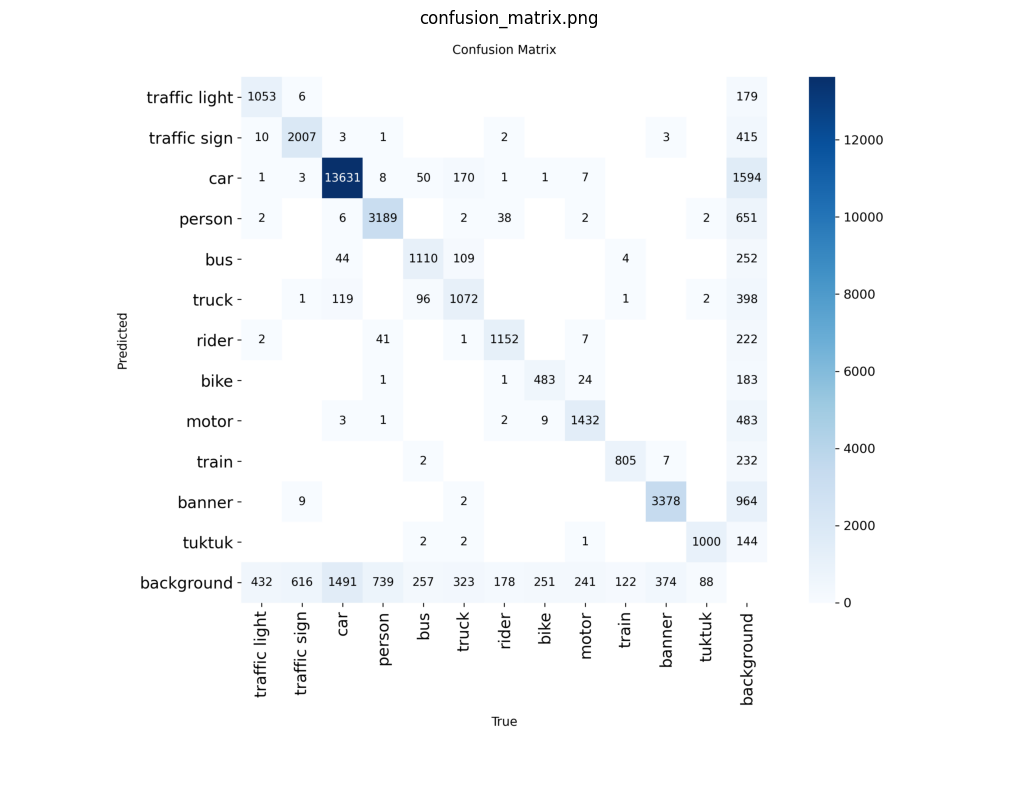

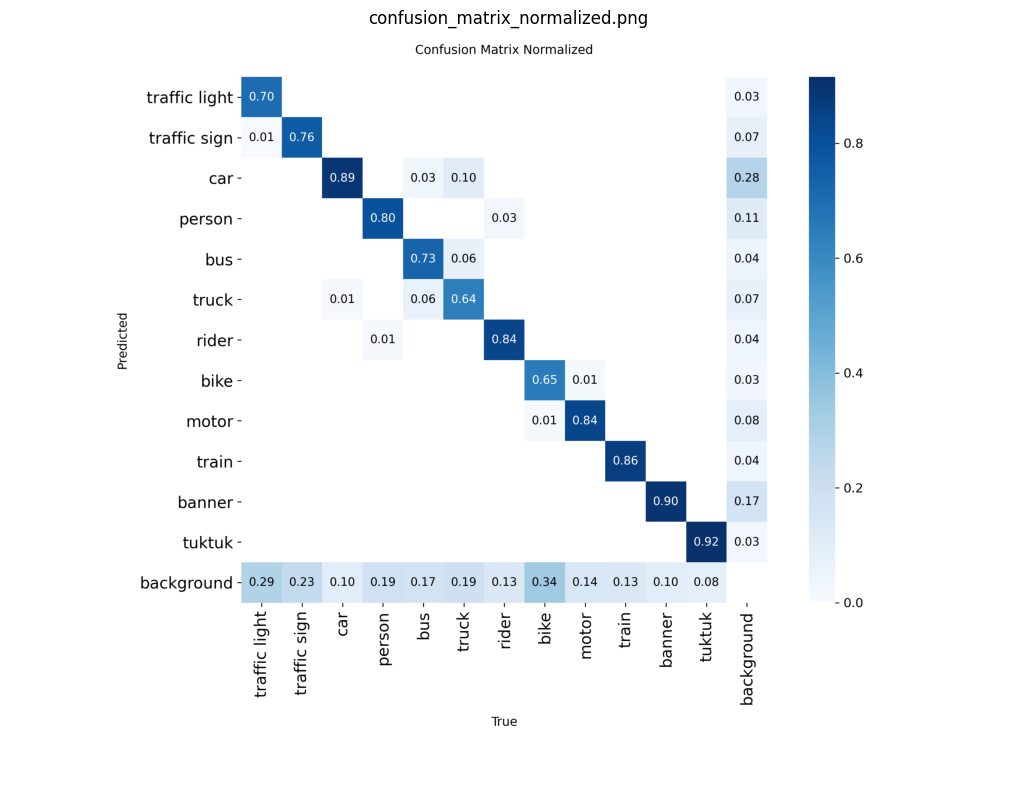

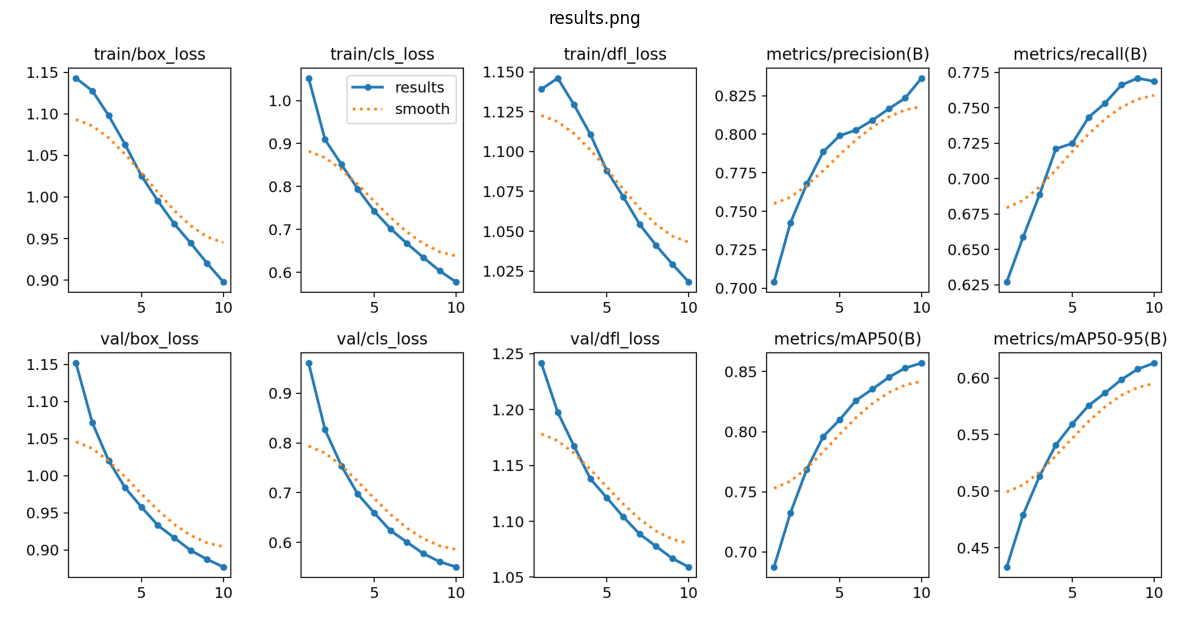

In [9]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# YOLOv8 auto-generates these during training and validation
plot_files = [
    f"runs/detect/runs/egypt_yolo/confusion_matrix.png",
    f"runs/detect/runs/egypt_yolo/confusion_matrix_normalized.png",
    f"runs/detect/runs/egypt_yolo/results.png",
    # f"{PROJECT_DIR}/{RUN_NAME}/PR_curve.png",
    # f"{PROJECT_DIR}/{RUN_NAME}/F1_curve.png",
]

for fpath in plot_files:
    if os.path.exists(fpath):
        img = mpimg.imread(fpath)
        plt.figure(figsize=(12, 8))
        plt.imshow(img)
        plt.title(os.path.basename(fpath))
        plt.axis('off')
        plt.tight_layout()
        plt.show()
    else:
        print(f"Not found: {fpath}")